<a href="https://colab.research.google.com/github/mayesalaslopez/Estadistica2025B/blob/main/Furniture_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/ingridmaitecastrovivero501-sketch/Estadistica2025B/refs/heads/main/Furniture.csv"
df = pd.read_csv(url)
df = df.dropna()
df

,price,cost,sales,profit_margin,inventory,discount_percentage,delivery_days,category,material,color,location,season,store_type,brand,revenue
0,218.543053,181.610932,40,16.899243,105,27.796433,9,Bed,Plastic,Red,Rural,Spring,Online,BrandA,3949.165238
1,477.821438,385.033827,7,19.418888,192,26.943715,6,Chair,Glass,Blue,Rural,Summer,Online,BrandD,-3521.002258
2,379.397274,276.736765,32,27.058842,59,21.948130,2,Table,Metal,Black,Suburban,Fall,Online,BrandD,14285.560219
3,319.396318,281.841334,48,11.758114,45,11.009944,2,Table,Glass,Green,Rural,Summer,Retail,BrandD,12261.073703
4,120.208388,69.743681,19,41.981019,35,3.183763,9,Chair,Glass,Brown,Rural,Fall,Online,BrandD,-4588.255733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,271.546466,233.247261,8,14.104107,102,9.789608,9,Chair,Metal,White,Suburban,Fall,Retail,BrandB,-3351.943350
2496,309.775563,169.680310,24,45.224760,9,21.835025,8,Bed,Glass,Red,Urban,Summer,Retail,BrandD,-445.621346
2497,439.509716,277.390903,48,36.886286,127,2.817299,6,Desk,Fabric,Red,Rural,Summer,Online,BrandD,25809.096038
2498,491.332705,405.987306,38,17.370185,6,19.781256,4,Desk,Metal,Black,Suburban,Fall,Retail,BrandA,18963.246944


In [ ]:
df.columns

Index(['price', 'cost', 'sales', 'profit_margin', 'inventory',
       'discount_percentage', 'delivery_days', 'category', 'material', 'color',
       'location', 'season', 'store_type', 'brand', 'revenue'],
      dtype='object')

In [ ]:
# a) Inspección y limpieza de datos.
#NOMBRES EN ESPAÑOL QUE DESCRIBEN CORRECTAMENTE EL CONTENIDO.
df.columns = ['precio', 'costo','ventas', 'margen_beneficio', 'inventario', 'porcentaje_descuento','dias_entrega','categoria','material','color','locacion','temporada','tipo_tienda','marca','ingresos' ]

df




,precio,costo,ventas,margen_beneficio,inventario,porcentaje_descuento,dias_entrega,categoria,material,color,locacion,temporada,tipo_tienda,marca,ingresos
0,218.543053,181.610932,40,16.899243,105,27.796433,9,Bed,Plastic,Red,Rural,Spring,Online,BrandA,3949.165238
1,477.821438,385.033827,7,19.418888,192,26.943715,6,Chair,Glass,Blue,Rural,Summer,Online,BrandD,-3521.002258
2,379.397274,276.736765,32,27.058842,59,21.948130,2,Table,Metal,Black,Suburban,Fall,Online,BrandD,14285.560219
3,319.396318,281.841334,48,11.758114,45,11.009944,2,Table,Glass,Green,Rural,Summer,Retail,BrandD,12261.073703
4,120.208388,69.743681,19,41.981019,35,3.183763,9,Chair,Glass,Brown,Rural,Fall,Online,BrandD,-4588.255733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,271.546466,233.247261,8,14.104107,102,9.789608,9,Chair,Metal,White,Suburban,Fall,Retail,BrandB,-3351.943350
2496,309.775563,169.680310,24,45.224760,9,21.835025,8,Bed,Glass,Red,Urban,Summer,Retail,BrandD,-445.621346
2497,439.509716,277.390903,48,36.886286,127,2.817299,6,Desk,Fabric,Red,Rural,Summer,Online,BrandD,25809.096038
2498,491.332705,405.987306,38,17.370185,6,19.781256,4,Desk,Metal,Black,Suburban,Fall,Retail,BrandA,18963.246944


In [ ]:
#Comentario: Se aplicó directamente el comando dropna () para eliminar filas con posibles valores nulos con el fin de asegurar que
#la base de datos esté completa y lista para realizar el análisis.

Index(['categoria', 'material', 'color', 'locacion', 'temporada',
       'tipo_tienda', 'marca'],
      dtype='object')


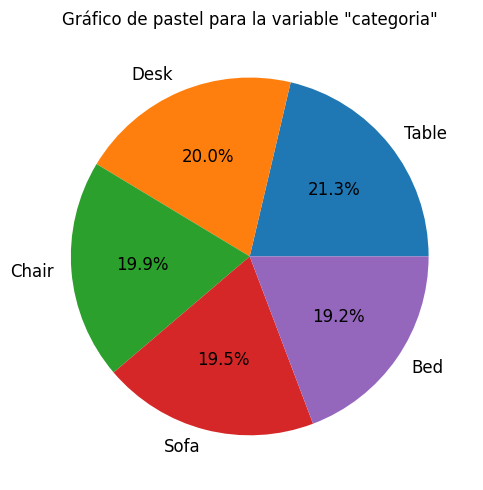

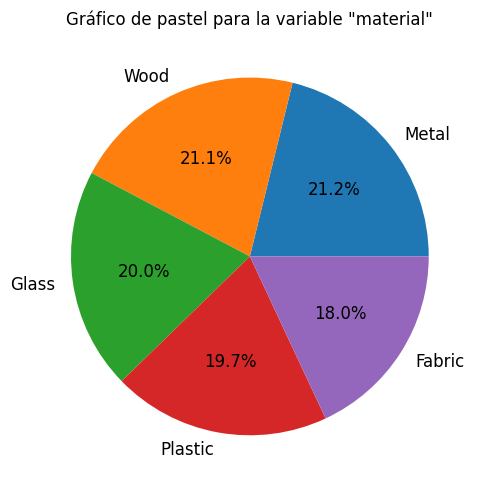

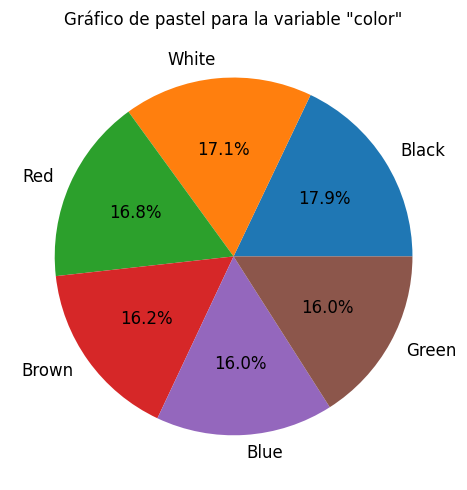

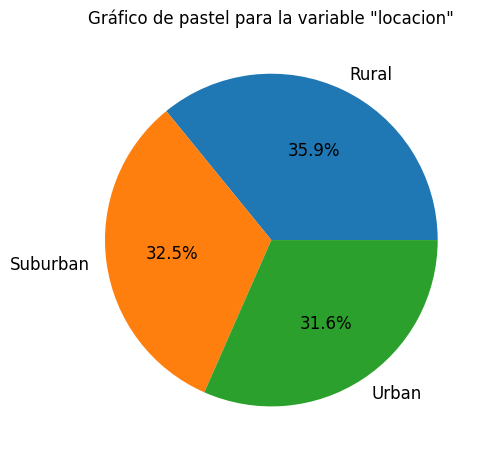

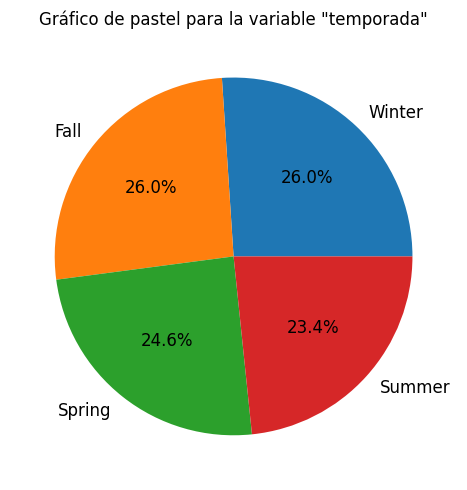

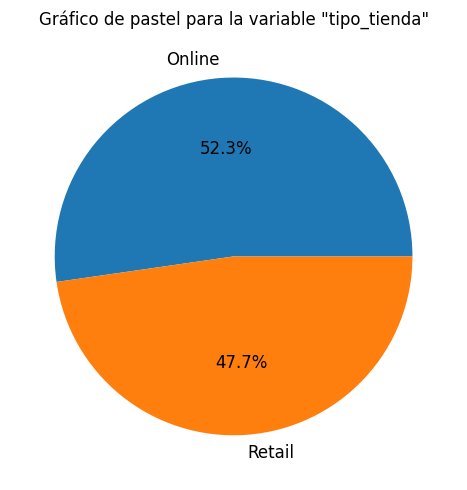

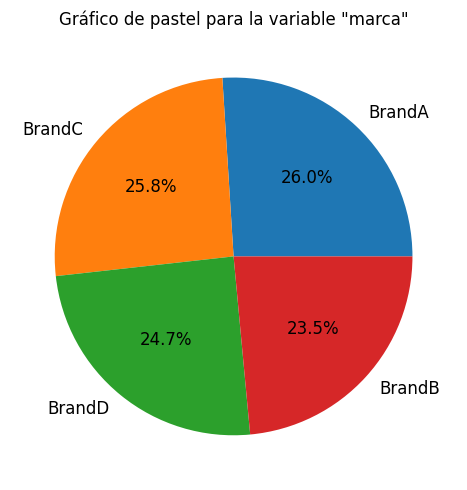

In [ ]:
#b)Variables categóricas y balanceo
import matplotlib.pyplot as plt

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)

for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(5, 5))

# 1) Las variables categoricas se analizan mediante la grafica de pastel que nos muestra el porcentaje
# que represeta cada categoría dentro de las variables cualitativas.
# Las variables category, material, color, season y brand están balanceadas por el porcentaje similar entre sí.
# La variable location se considera medianamente balanceada
# La variable tipo de tienda se encuentra desbalanceada por la mayor representacion de ventas.

    df[col].value_counts(dropna=False).plot.pie(
        autopct='%1.1f%%',
        ax=ax,
        shadow=False,
        textprops={'fontsize': 12}
    )
    ax.set_title(f'Gráfico de pastel para la variable "{col}"', fontsize=12)
    ax.set_ylabel('')

    plt.tight_layout()
    plt.show()

# 2) Cuando una variable categórica está balanceada el modelo aprende de todas las categorías por igual y puede hacer mejores predicciones.
# Cuando está desbalanceada el modelo se vuelve parcial hacia la categoría con más datos y puede fallar al predecir correctamente las categorías minoritarias.

In [ ]:
#Categoría: Está balanceada, ya que todas las categorías (Table, Desk, Chair, Sofa y Bed) tienen porcentajes muy parecidos, alrededor del 20%.
#Material: la variable está balanceada, ya que ninguna categoría dentro de esta variable domina de forma importante sobre las demás en donde los porcentajes de cada categoría son muy parecidos.
#Color: la variable está balanceada, porque los colores tienen proporciones casi iguales y ningúno destaca mucho sobre los demás.
#Locación: Está balanceada aunque tiene un ligera diferencia ya que la categoría Rural tiene un poco más de registros que Suburban y Urban pero no domina de forma importante a las demás.
#Temporada: presenta proporciones similares, por lo que esta variable al igual que las anteriores se encuentra balanceada.
#Tipo tienda": Nos indica que está balanceada, ya que la diferencia entre ambas categorías es pequeña, por lo que los datos están equilibrados.
#Marca: se encuentra balanceada, porque las cuatro marcas tienen porcentajes muy similares, entre el rango de 23.5% y 26% lo que nos indica que no hay una marca con una representación muy baja o excesiva.
#Implicaciones:
#Cuando una variable está balanceada, el modelo aprende de manera justa sobre todas las categorías, lo que mejora su precisión y evita que favorezca una más que otra.
#En cambio, si una variable está desbalanceada, el modelo puede aprender más de las categorías con más datos y cometer errores o sesgos al predecir las que tienen menos información.

In [ ]:
#C)Modelo ANOVA.
#CONSIDERANDO TODAS LAS VARIABLES DISPONIBLES.
from statsmodels.formula.api import ols
import statsmodels.api as sm
#Y~X
modelo_lineal = ols(
    'precio ~ costo + ventas + margen_beneficio + inventario	+ porcentaje_descuento + dias_entrega	+ C(categoria)	+ C(material)	+ C(color)	+ C(locacion)	+ C(temporada)	+ C(tipo_tienda)	+ C(marca) + ingresos',
    data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
C(categoria),4.0,9.657745e+04,2.414436e+04,51.554198,9.439574e-42
C(material),4.0,8.895205e+04,2.223801e+04,47.483664,1.642059e-38
C(color),5.0,3.360018e+04,6.720036e+03,14.348941,7.101209e-14
C(locacion),2.0,6.284114e+04,3.142057e+04,67.090703,4.234123e-29
C(temporada),3.0,3.940800e+04,1.313600e+04,28.048617,7.846721e-18
C(tipo_tienda),1.0,6.042131e+02,6.042131e+02,1.290145,2.561315e-01
C(marca),3.0,3.198871e+04,1.066290e+04,22.767941,1.545171e-14
costo,1.0,3.693319e+07,3.693319e+07,78861.501579,0.000000e+00
ventas,1.0,2.565956e+03,2.565956e+03,5.478952,1.932597e-02
margen_beneficio,1.0,4.363054e+06,4.363054e+06,9316.200385,0.000000e+00


In [ ]:
#Las variables más relevantes que influyen significativamente en el precio son la categoria, material,color,locacion,temporada
#marca, costo, ventas, margen de beneficio e ingresos debido a que su valor-p es menor al nivel de significancia por lo que se rechaza la hipótesis nula y nos indica que si hay diferencia significativa;
#mientras que las variables que no influyen significativamente son el tipo tipo tienda, inventario,
#porcentaje descuento y los días de entrega debido a que estos tienen un valor-p mayor al nivel de significancia de 0.05 lo que en este
#caso no se rechaza la hipótesis nula por lo que no hay diferencia significativa.

In [ ]:
#Test de Tukey y codificación
#variables categóricas significativas en el ANOVA
df["categoria"].unique()

array(['Bed', 'Chair', 'Table', 'Sofa', 'Desk'], dtype=object)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   Bed  Chair  12.1689 0.5927 -10.6785 35.0163  False
   Bed   Desk  18.7634 0.1632  -4.0391 41.5659  False
   Bed   Sofa  13.6787 0.4802  -9.2721 36.6295  False
   Bed  Table   14.382 0.4049  -8.0828 36.8467  False
 Chair   Desk   6.5945 0.9318 -16.0199  29.209  False
 Chair   Sofa   1.5098 0.9998 -21.2542 24.2738  False
 Chair  Table   2.2131 0.9988 -20.0608 24.4869  False
  Desk   Sofa  -5.0847 0.9734 -27.8036 17.6342  False
  Desk  Table  -4.3815 0.9834 -26.6093 17.8463  False
  Sofa  Table   0.7032    1.0 -21.6766 23.0831  False
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

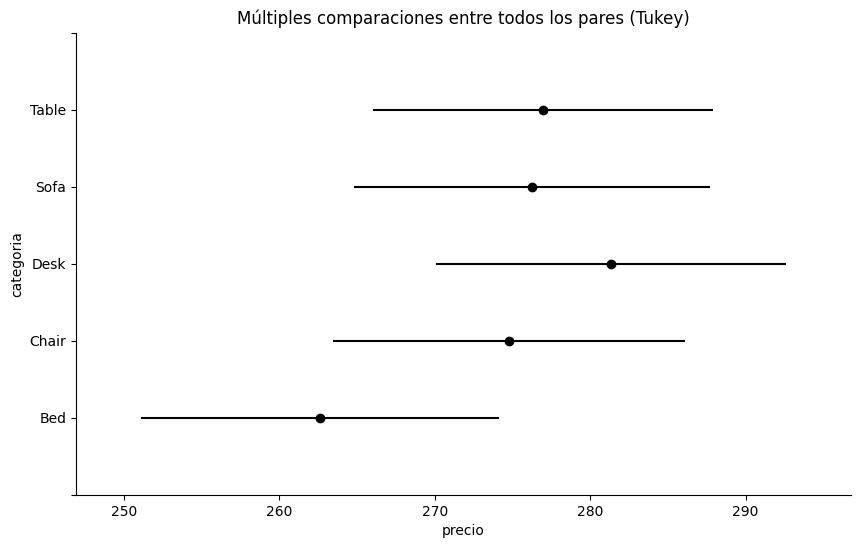

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['precio'], #variable de respuesta
    groups=df['categoria'], #variable categorica
    alpha=nivel_de_significancia) #nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="categoria", xlabel="precio")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

#Muestra los intervalos o niveles de confianza en las lineas, lo cual según el gráfico la variable categoría
#que tiene un precio de venta más elevado es Desk al cual mediante el gráfico de múltiples comparaciones
#o conforme a esta prueba se asignaron valores a las categoría de los muebles según el promedio del precio
#en donde se le asignó a Desk 4, Table 3, Sofa 2, Chair 1 y a Bed 0 el cual este tiene un precio de venta menor a los anteriores.
#Conforma a la prueba de tukey no existe o no hay diferencia entre los grupos.

In [ ]:
df["categoria"]=df["categoria"].map({"Bed":0,"Chair":1, "Sofa":2, "Table":3,"Desk":4})
df

,precio,costo,ventas,margen_beneficio,inventario,porcentaje_descuento,dias_entrega,categoria,material,color,locacion,temporada,tipo_tienda,marca,ingresos
0,218.543053,181.610932,40,16.899243,105,27.796433,9,0,Plastic,Red,Rural,Spring,Online,BrandA,3949.165238
1,477.821438,385.033827,7,19.418888,192,26.943715,6,1,Glass,Blue,Rural,Summer,Online,BrandD,-3521.002258
2,379.397274,276.736765,32,27.058842,59,21.948130,2,3,Metal,Black,Suburban,Fall,Online,BrandD,14285.560219
3,319.396318,281.841334,48,11.758114,45,11.009944,2,3,Glass,Green,Rural,Summer,Retail,BrandD,12261.073703
4,120.208388,69.743681,19,41.981019,35,3.183763,9,1,Glass,Brown,Rural,Fall,Online,BrandD,-4588.255733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,271.546466,233.247261,8,14.104107,102,9.789608,9,1,Metal,White,Suburban,Fall,Retail,BrandB,-3351.943350
2496,309.775563,169.680310,24,45.224760,9,21.835025,8,0,Glass,Red,Urban,Summer,Retail,BrandD,-445.621346
2497,439.509716,277.390903,48,36.886286,127,2.817299,6,4,Fabric,Red,Rural,Summer,Online,BrandD,25809.096038
2498,491.332705,405.987306,38,17.370185,6,19.781256,4,4,Metal,Black,Suburban,Fall,Retail,BrandA,18963.246944


In [ ]:
df["material"].unique()

array(['Plastic', 'Glass', 'Metal', 'Wood', 'Fabric'], dtype=object)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
 Fabric   Glass -16.3299  0.306 -39.5288  6.8691  False
 Fabric   Metal -14.3415 0.4279  -37.237  8.5539  False
 Fabric Plastic -15.6566 0.3534 -38.9449  7.6316  False
 Fabric    Wood  -8.0018 0.8757 -30.9072 14.9035  False
  Glass   Metal   1.9883 0.9992 -20.2933 24.2699  False
  Glass Plastic   0.6733    1.0 -22.0118 23.3583  False
  Glass    Wood   8.3281 0.8463 -13.9638 30.6199  False
  Metal Plastic  -1.3151 0.9999 -23.6896 21.0594  False
  Metal    Wood   6.3397 0.9343  -15.636 28.3155  False
Plastic    Wood   7.6548 0.8839 -14.7299 30.0395  False
-------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

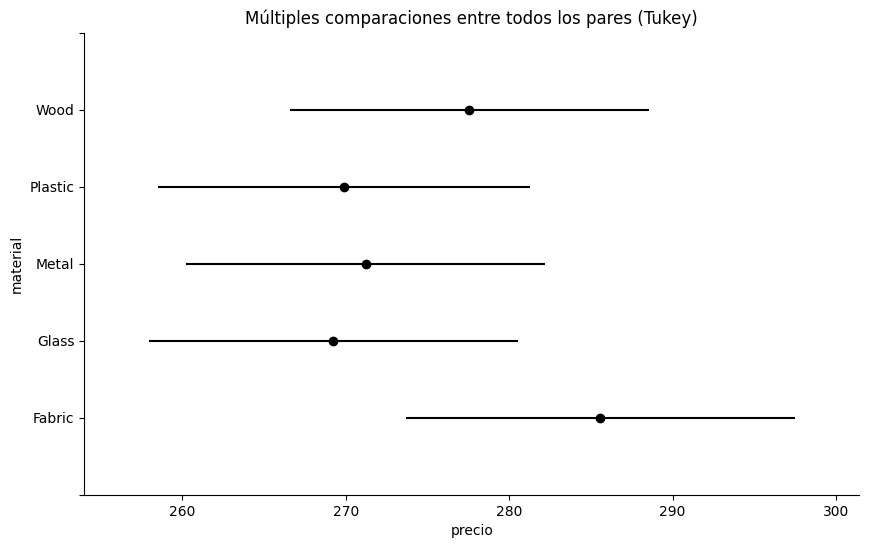

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['precio'], #variable de respuesta
    groups=df['material'], #variable categorica
    alpha=nivel_de_significancia) #nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="material", xlabel="precio")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

#Muestra los intervalos o niveles de confianza en las lineas, lo cual según el gráfico dentro de la variable material
#que tiene un precio de venta más elevado es Fabric. A cada material se le asignaron valores respetando el orden obtenido en la prueba de
#Tukey conforme al promedio del precio en un orden ascendente en donde al material Glass se le asignó un valor de 0 ya que es el que tiene el precio más bajo, a Plastic=
#1, Metal=2, Wood tiene el valor de 3 en donde presenta un precio un poco
#más alto y a Fabric se le asignó el valor 4 ya que este tiene un precio de venta más elevado. Tukey nos permitó observar que no existe diferencia entre los grupos dentro de la variable material
#en donde de la misma manera como fue mencionado al inicio considerando esta oción y conforme al gráfico se le podría asignar a los materiales plastic, metal, y glass el mismo valor
#pero para obtener un orden apun mejor se le asignó un valor a cada material iniciando del más bajo al más alto.


In [ ]:
df["material"]=df["material"].map({"Glass":0,"Plastic":1, "Metal":2, "Wood":3,"Fabric":4})
df

,precio,costo,ventas,margen_beneficio,inventario,porcentaje_descuento,dias_entrega,categoria,material,color,locacion,temporada,tipo_tienda,marca,ingresos
0,218.543053,181.610932,40,16.899243,105,27.796433,9,0,1,Red,Rural,Spring,Online,BrandA,3949.165238
1,477.821438,385.033827,7,19.418888,192,26.943715,6,1,0,Blue,Rural,Summer,Online,BrandD,-3521.002258
2,379.397274,276.736765,32,27.058842,59,21.948130,2,3,2,Black,Suburban,Fall,Online,BrandD,14285.560219
3,319.396318,281.841334,48,11.758114,45,11.009944,2,3,0,Green,Rural,Summer,Retail,BrandD,12261.073703
4,120.208388,69.743681,19,41.981019,35,3.183763,9,1,0,Brown,Rural,Fall,Online,BrandD,-4588.255733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,271.546466,233.247261,8,14.104107,102,9.789608,9,1,2,White,Suburban,Fall,Retail,BrandB,-3351.943350
2496,309.775563,169.680310,24,45.224760,9,21.835025,8,0,0,Red,Urban,Summer,Retail,BrandD,-445.621346
2497,439.509716,277.390903,48,36.886286,127,2.817299,6,4,4,Red,Rural,Summer,Online,BrandD,25809.096038
2498,491.332705,405.987306,38,17.370185,6,19.781256,4,4,2,Black,Suburban,Fall,Retail,BrandA,18963.246944


In [ ]:
df["color"].unique()

array(['Red', 'Blue', 'Black', 'Green', 'Brown', 'White'], dtype=object)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
 Black   Blue  -6.6588  0.977 -32.3394 19.0218  False
 Black  Brown  -6.3939 0.9805 -31.9909 19.2031  False
 Black  Green  -6.9891 0.9717 -32.7037 18.7254  False
 Black    Red  -0.2042    1.0 -25.5921 25.1836  False
 Black  White   0.4321    1.0 -24.8326 25.6967  False
  Blue  Brown   0.2649    1.0 -26.0356 26.5654  False
  Blue  Green  -0.3304    1.0 -26.7452 26.0845  False
  Blue    Red   6.4546 0.9813 -19.6424 32.5516  False
  Blue  White   7.0908 0.9712 -18.8863  33.068  False
 Brown  Green  -0.5952    1.0 -26.9289 25.7384  False
 Brown    Red   6.1897 0.9843  -19.825 32.2045  False
 Brown  White    6.826 0.9753 -19.0685 32.7205  False
 Green    Red   6.7849 0.9769 -19.3454 32.9153  False
 Green  White   7.4212 0.9651 -18.5895 33.4319  False
   Red  White   0.6363    1.0 -25.0515 26.3241  False
----------------------------

Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

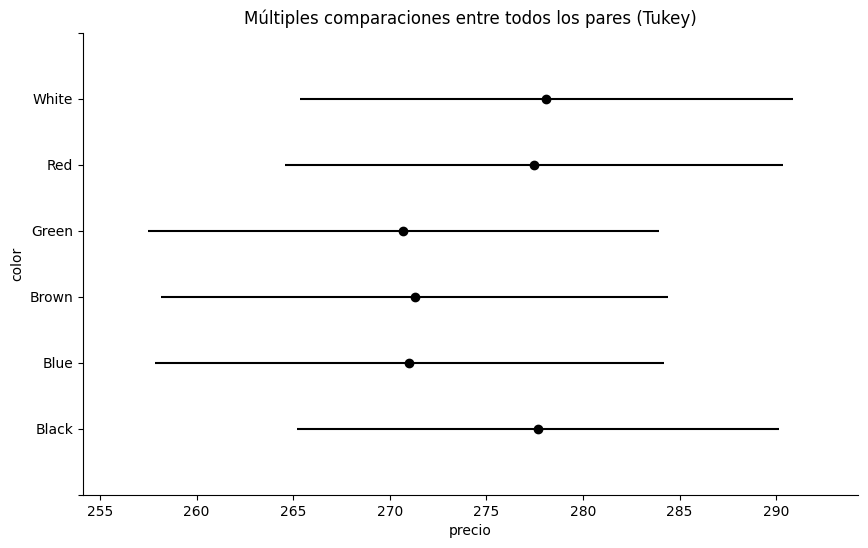

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['precio'], #variable de respuesta
    groups=df['color'], #variable categorica
    alpha=nivel_de_significancia) #nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="color", xlabel="precio")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

#Muestra los intervalos o niveles de confianza en las lineas, lo cual según el gráfico dentro de la variable color
#donde el color que tiene un precio de venta más elevado es White. A cada color se le asignaron valores de manera ascendente respetanto el orden obtenido en la prueba de Tukey
#conforme a lo que es el promedio del precio en el que al color green se le asignó cero ya que tiene el precio más bajo, Blue=1, Brown=2, Red=3, Black=4
#y White=5 el cual este último color como antes fue mencionado tiene el precio más alto. La prueba de tukey nos permitió adempas el observar que entre los grupos dentro de la variable de
#no tienen diferencia alguna por lo que sería posible al igual asignarle los mismos valores al grupo de greeen, brown y blue al igual que al grupo de white y red pero se consideró agregar un valor
#a cada variable a fin de representar los tipos de colores de una manera más ordenada.

In [ ]:
df["color"]=df["color"].map({"Green":0,"Blue":1, "Brown":2, "Red":3,"Black":4, "White":5})
df

,precio,costo,ventas,margen_beneficio,inventario,porcentaje_descuento,dias_entrega,categoria,material,color,locacion,temporada,tipo_tienda,marca,ingresos
0,218.543053,181.610932,40,16.899243,105,27.796433,9,0,1,3,Rural,Spring,Online,BrandA,3949.165238
1,477.821438,385.033827,7,19.418888,192,26.943715,6,1,0,1,Rural,Summer,Online,BrandD,-3521.002258
2,379.397274,276.736765,32,27.058842,59,21.948130,2,3,2,4,Suburban,Fall,Online,BrandD,14285.560219
3,319.396318,281.841334,48,11.758114,45,11.009944,2,3,0,0,Rural,Summer,Retail,BrandD,12261.073703
4,120.208388,69.743681,19,41.981019,35,3.183763,9,1,0,2,Rural,Fall,Online,BrandD,-4588.255733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,271.546466,233.247261,8,14.104107,102,9.789608,9,1,2,5,Suburban,Fall,Retail,BrandB,-3351.943350
2496,309.775563,169.680310,24,45.224760,9,21.835025,8,0,0,3,Urban,Summer,Retail,BrandD,-445.621346
2497,439.509716,277.390903,48,36.886286,127,2.817299,6,4,4,3,Rural,Summer,Online,BrandD,25809.096038
2498,491.332705,405.987306,38,17.370185,6,19.781256,4,4,2,4,Suburban,Fall,Retail,BrandA,18963.246944


In [ ]:
df["locacion"].unique()

array(['Rural', 'Suburban', 'Urban'], dtype=object)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
   Rural Suburban   3.8272 0.8179 -11.0323 18.6867  False
   Rural    Urban  -8.4754   0.38  -23.448  6.4971  False
Suburban    Urban -12.3026 0.1441 -27.6331  3.0279  False
---------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

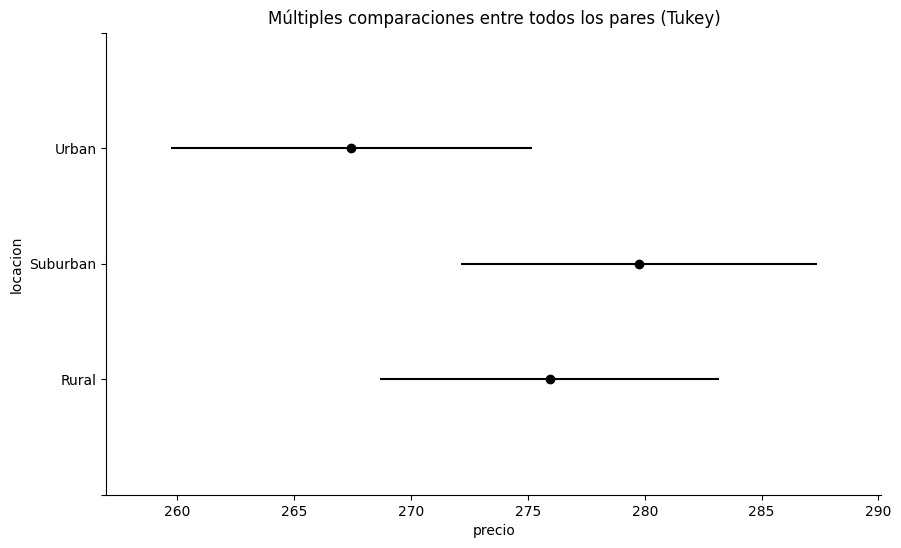

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['precio'], #variable de respuesta
    groups=df['locacion'], #variable categorica
    alpha=nivel_de_significancia) #nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="locacion", xlabel="precio")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

#Muestra los intervalos o niveles de confianza en las lineas, lo cual según el gráfico dentro de la variable locacion
#que tiene un precio de venta más elevado es Suburban. Conforme a la prueba de tukey a cada locacion se le asignó un valor de orden ascendente
#conforme el promedio del precio en donde se le asignó el valor cero a la locación urban debido a que está tiene el precio más bajo,
#Rural se le asignó un valor de 1 ya que tiene un precio medio o que es un poco más alto que el anterior y a la última locación el valor que se le dió un
#valor de 2 debido a que tiene el precio más alto.

In [ ]:
df["locacion"]=df["locacion"].map({"Urban":0,"Rural":1, "Suburban":2})
df

,precio,costo,ventas,margen_beneficio,inventario,porcentaje_descuento,dias_entrega,categoria,material,color,locacion,temporada,tipo_tienda,marca,ingresos
0,218.543053,181.610932,40,16.899243,105,27.796433,9,0,1,3,1,Spring,Online,BrandA,3949.165238
1,477.821438,385.033827,7,19.418888,192,26.943715,6,1,0,1,1,Summer,Online,BrandD,-3521.002258
2,379.397274,276.736765,32,27.058842,59,21.948130,2,3,2,4,2,Fall,Online,BrandD,14285.560219
3,319.396318,281.841334,48,11.758114,45,11.009944,2,3,0,0,1,Summer,Retail,BrandD,12261.073703
4,120.208388,69.743681,19,41.981019,35,3.183763,9,1,0,2,1,Fall,Online,BrandD,-4588.255733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,271.546466,233.247261,8,14.104107,102,9.789608,9,1,2,5,2,Fall,Retail,BrandB,-3351.943350
2496,309.775563,169.680310,24,45.224760,9,21.835025,8,0,0,3,0,Summer,Retail,BrandD,-445.621346
2497,439.509716,277.390903,48,36.886286,127,2.817299,6,4,4,3,1,Summer,Online,BrandD,25809.096038
2498,491.332705,405.987306,38,17.370185,6,19.781256,4,4,2,4,2,Fall,Retail,BrandA,18963.246944


In [ ]:
df["temporada"].unique()

array(['Spring', 'Summer', 'Fall', 'Winter'], dtype=object)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
  Fall Spring  -1.5262 0.9969 -20.4601 17.4077  False
  Fall Summer  -5.1699 0.8999 -24.3524 14.0126  False
  Fall Winter  -9.8403 0.5272 -28.4952  8.8146  False
Spring Summer  -3.6437 0.9632 -23.0976 15.8102  False
Spring Winter  -8.3141 0.6717  -27.248 10.6198  False
Summer Winter  -4.6704 0.9238 -23.8529 14.5121  False
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

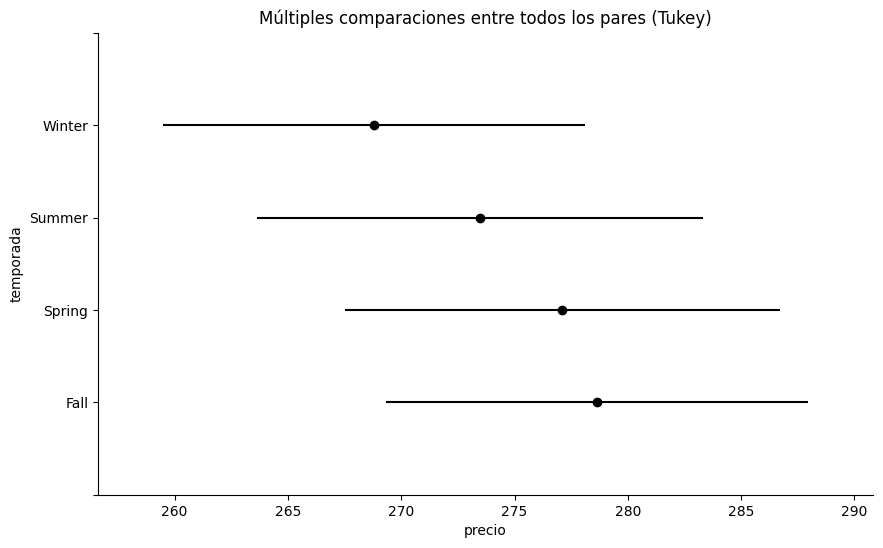

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['precio'], #variable de respuesta
    groups=df['temporada'], #variable categorica
    alpha=nivel_de_significancia) #nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="temporada", xlabel="precio")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

#Muestra los intervalos o niveles de confianza en las lineas, lo cual según el gráfico dentro de la variable temporada
#que tiene un precio de venta más elevado es Fall. A cada temporada se le asignó un valor de forma ascendente conforme al orden obtenido en la prueba de tukey
#conforme el promedio del precio en donde Winter tiene el precio más bajo y se le dió el valor de 0, Summer=1, Spring=2 y a Fall se le asignó
#el valor de 3 por la razón comentada al inicio. Por lo que además conforme a la prueba de tukey se ha logrado observar que no hay diferencia entre cada uno de estos
#grupos en doonde es posible agregar para el grupo spring y fall un mismo valor pero se consideró agregar un valor a cada grupo a fin de representar
#los valores de los grupos de las variables de manera ordenada.

In [ ]:
df["temporada"]=df["temporada"].map({"Winter":0,"Summer":1, "Spring":2, "Fall":3})
df

,precio,costo,ventas,margen_beneficio,inventario,porcentaje_descuento,dias_entrega,categoria,material,color,locacion,temporada,tipo_tienda,marca,ingresos
0,218.543053,181.610932,40,16.899243,105,27.796433,9,0,1,3,1,2,Online,BrandA,3949.165238
1,477.821438,385.033827,7,19.418888,192,26.943715,6,1,0,1,1,1,Online,BrandD,-3521.002258
2,379.397274,276.736765,32,27.058842,59,21.948130,2,3,2,4,2,3,Online,BrandD,14285.560219
3,319.396318,281.841334,48,11.758114,45,11.009944,2,3,0,0,1,1,Retail,BrandD,12261.073703
4,120.208388,69.743681,19,41.981019,35,3.183763,9,1,0,2,1,3,Online,BrandD,-4588.255733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,271.546466,233.247261,8,14.104107,102,9.789608,9,1,2,5,2,3,Retail,BrandB,-3351.943350
2496,309.775563,169.680310,24,45.224760,9,21.835025,8,0,0,3,0,1,Retail,BrandD,-445.621346
2497,439.509716,277.390903,48,36.886286,127,2.817299,6,4,4,3,1,1,Online,BrandD,25809.096038
2498,491.332705,405.987306,38,17.370185,6,19.781256,4,4,2,4,2,3,Retail,BrandA,18963.246944


In [ ]:
df["tipo_tienda"].unique()

array(['Online', 'Retail'], dtype=object)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Online Retail  -0.5195 0.9211 -10.7994 9.7605  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

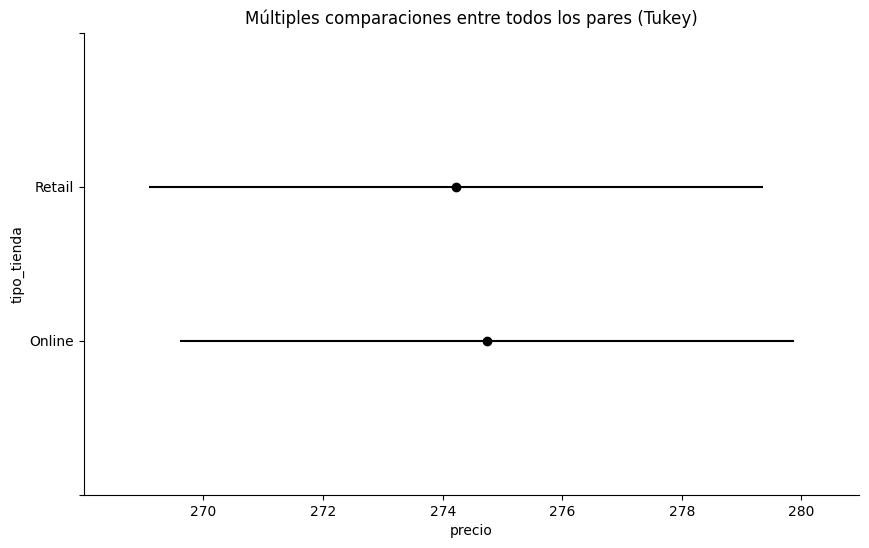

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['precio'], #variable de respuesta
    groups=df['tipo_tienda'], #variable categorica
    alpha=nivel_de_significancia) #nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="tipo_tienda", xlabel="precio")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

#Muestra los intervalos o niveles de confianza en las lineas, lo cual según el gráfico dentro de la variable tipo tienda
#que tiene un precio de venta más elevado es Online. En relación a la prueba de tukey se le asignaron valores a cada uno de los tipos de tienda
#en un orden ascendente conforme el promedio del precio en donde al tipo de tienda llamada Retail se le asignó el valor menor o en este caso
#el cero debido a que tiene un precio menor y online se le asignó el valor 1 porque tiene el precio más alto. Tukey además nos muestra que no
#existe diferencia entre estos dos grupos dentro de la variable tipo tienda donde se les puede asginar el mismo valor pero se consideró agregar un valor a cada grupo a fin de representar
#la variable de manera ordenada.

In [ ]:
df["tipo_tienda"]=df["tipo_tienda"].map({"Retail":0,"Online":1})
df

,precio,costo,ventas,margen_beneficio,inventario,porcentaje_descuento,dias_entrega,categoria,material,color,locacion,temporada,tipo_tienda,marca,ingresos
0,218.543053,181.610932,40,16.899243,105,27.796433,9,0,1,3,1,2,1,BrandA,3949.165238
1,477.821438,385.033827,7,19.418888,192,26.943715,6,1,0,1,1,1,1,BrandD,-3521.002258
2,379.397274,276.736765,32,27.058842,59,21.948130,2,3,2,4,2,3,1,BrandD,14285.560219
3,319.396318,281.841334,48,11.758114,45,11.009944,2,3,0,0,1,1,0,BrandD,12261.073703
4,120.208388,69.743681,19,41.981019,35,3.183763,9,1,0,2,1,3,1,BrandD,-4588.255733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,271.546466,233.247261,8,14.104107,102,9.789608,9,1,2,5,2,3,0,BrandB,-3351.943350
2496,309.775563,169.680310,24,45.224760,9,21.835025,8,0,0,3,0,1,0,BrandD,-445.621346
2497,439.509716,277.390903,48,36.886286,127,2.817299,6,4,4,3,1,1,1,BrandD,25809.096038
2498,491.332705,405.987306,38,17.370185,6,19.781256,4,4,2,4,2,3,0,BrandA,18963.246944


In [ ]:
df["marca"].unique()

array(['BrandA', 'BrandD', 'BrandB', 'BrandC'], dtype=object)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
BrandA BrandB   0.0433    1.0 -19.1132 19.1998  False
BrandA BrandC   7.7988 0.7071 -10.9153 26.5129  False
BrandA BrandD   6.0373 0.8447 -12.8735  24.948  False
BrandB BrandC   7.7555 0.7268 -11.4433 26.9543  False
BrandB BrandD   5.9939 0.8569 -13.3967 25.3846  False
BrandC BrandD  -1.7615 0.9952 -20.7152 17.1921  False
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

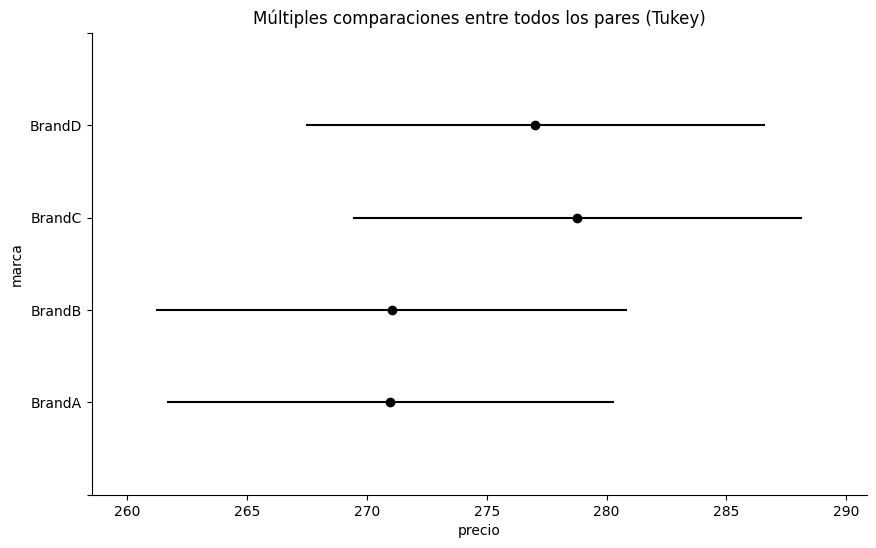

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['precio'], #variable de respuesta
    groups=df['marca'], #variable categorica
    alpha=nivel_de_significancia) #nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="marca", xlabel="precio")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

#Muestra los intervalos o niveles de confianza en las lineas, lo cual según el gráfico dentro de la variable marca
#que tiene un precio de venta más elevado es BrandC. A cada marca se le dió un valor de manera ascendente en relación al orden obtenido en la prueba de tukey
#conforme el prodio del precio en el que a la marca BrandB se le dió el valor de 0 porque tiene el precio más bajo, BrandA=1, BrandD=2 y a la última marca se le asignó
#el valor 3 debido a que esta tiene el precio más elevado o alto. La prueba de tukey además nos permitió observar que en cada grupo no hay diferencia dentro de la variable en donde a
#la clase BrandA y B se les puede asignar el mismo valor al igual que las otras dos clases
#pero se consideró agregar un valor a cada grupo para representar la variable marca de una manera ordenada.

In [ ]:
df["marca"]=df["marca"].map({"BrandB":0,"BrandA":1, "BrandD":2, "BrandC":3})
df

,precio,costo,ventas,margen_beneficio,inventario,porcentaje_descuento,dias_entrega,categoria,material,color,locacion,temporada,tipo_tienda,marca,ingresos
0,218.543053,181.610932,40,16.899243,105,27.796433,9,0,1,3,1,2,1,1,3949.165238
1,477.821438,385.033827,7,19.418888,192,26.943715,6,1,0,1,1,1,1,2,-3521.002258
2,379.397274,276.736765,32,27.058842,59,21.948130,2,3,2,4,2,3,1,2,14285.560219
3,319.396318,281.841334,48,11.758114,45,11.009944,2,3,0,0,1,1,0,2,12261.073703
4,120.208388,69.743681,19,41.981019,35,3.183763,9,1,0,2,1,3,1,2,-4588.255733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,271.546466,233.247261,8,14.104107,102,9.789608,9,1,2,5,2,3,0,0,-3351.943350
2496,309.775563,169.680310,24,45.224760,9,21.835025,8,0,0,3,0,1,0,2,-445.621346
2497,439.509716,277.390903,48,36.886286,127,2.817299,6,4,4,3,1,1,1,2,25809.096038
2498,491.332705,405.987306,38,17.370185,6,19.781256,4,4,2,4,2,3,0,1,18963.246944


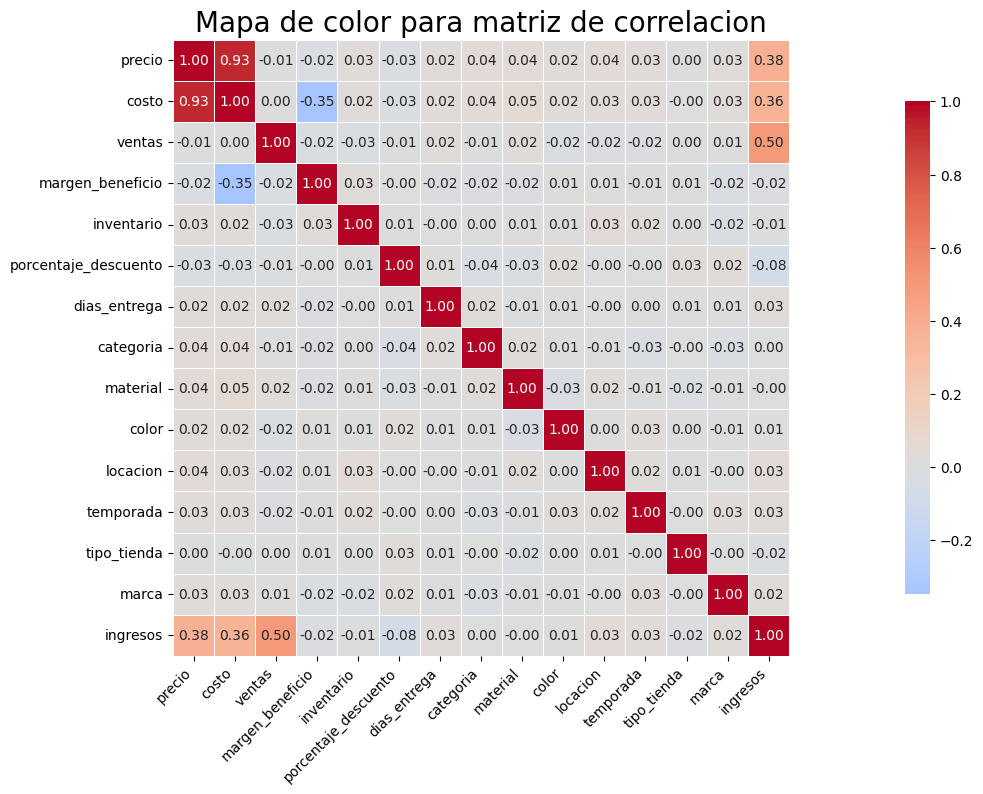

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

matriz_de_correlacion= df.corr()

plt.figure(figsize=(30,8), dpi= 100)

sns.heatmap(
    matriz_de_correlacion, #lo que va a graficar
    annot= True, #se muestran los valores en las celdas
    fmt= "0.2f", #0.2f significa "dos decimales"
    cmap= "coolwarm", #paleta de colores
    square= True, #forzar cuadrados
    linewidths= 0.5, #grosor de lineas
    cbar_kws= {"shrink":0.8}, #tamaño barra lateral
    center= 0,
    )

plt.title("Mapa de color para matriz de correlacion", fontsize=20)
plt.xticks(rotation= 45, ha= "right")
plt.yticks(rotation= 0)
plt.show()

In [ ]:
matriz_de_correlacion["costo"].sort_values()

,costo
margen_beneficio,-0.346914
porcentaje_descuento,-0.026598
tipo_tienda,-0.003456
ventas,0.001666
color,0.016916
inventario,0.018150
dias_entrega,0.024013
marca,0.026063
temporada,0.027608
locacion,0.030975


In [ ]:
matriz_de_correlacion["ventas"].sort_values()

,ventas
inventario,-0.028932
margen_beneficio,-0.022618
color,-0.021587
locacion,-0.016759
temporada,-0.016609
categoria,-0.009996
porcentaje_descuento,-0.008092
precio,-0.006363
tipo_tienda,0.000646
costo,0.001666


In [ ]:
matriz_de_correlacion["margen_beneficio"].sort_values()

,margen_beneficio
costo,-0.346914
precio,-0.023581
ventas,-0.022618
marca,-0.021227
categoria,-0.019607
ingresos,-0.018424
material,-0.018393
dias_entrega,-0.016404
temporada,-0.014662
porcentaje_descuento,-0.000530


In [ ]:
matriz_de_correlacion["inventario"].sort_values()

,inventario
ventas,-0.028932
marca,-0.024677
ingresos,-0.013378
dias_entrega,-0.003220
tipo_tienda,0.003527
categoria,0.004013
porcentaje_descuento,0.006816
color,0.010490
material,0.013026
temporada,0.017278


In [ ]:
matriz_de_correlacion["porcentaje_descuento"].sort_values()

,porcentaje_descuento
ingresos,-0.078548
categoria,-0.035518
costo,-0.026598
material,-0.025917
precio,-0.025858
ventas,-0.008092
temporada,-0.003607
margen_beneficio,-0.000530
locacion,-0.000278
inventario,0.006816


In [ ]:
matriz_de_correlacion["dias_entrega"].sort_values()

,dias_entrega
margen_beneficio,-0.016404
material,-0.013122
locacion,-0.003820
inventario,-0.003220
temporada,0.002626
tipo_tienda,0.005178
marca,0.006712
color,0.008809
porcentaje_descuento,0.011201
precio,0.016220


In [ ]:
matriz_de_correlacion["categoria"].sort_values()

,categoria
porcentaje_descuento,-0.035518
temporada,-0.030613
marca,-0.025328
margen_beneficio,-0.019607
ventas,-0.009996
locacion,-0.007345
tipo_tienda,-0.003261
ingresos,0.000255
inventario,0.004013
color,0.005253


In [ ]:
matriz_de_correlacion["material"].sort_values()

,material
color,-0.034005
porcentaje_descuento,-0.025917
tipo_tienda,-0.022826
margen_beneficio,-0.018393
dias_entrega,-0.013122
marca,-0.010707
temporada,-0.008775
ingresos,-0.000558
inventario,0.013026
categoria,0.017364


In [ ]:
matriz_de_correlacion["color"].sort_values()

,color
material,-0.034005
ventas,-0.021587
marca,-0.006860
locacion,0.000629
tipo_tienda,0.004061
categoria,0.005253
dias_entrega,0.008809
inventario,0.010490
ingresos,0.011573
margen_beneficio,0.012234


In [ ]:
matriz_de_correlacion["locacion"].sort_values()

,locacion
ventas,-0.016759
categoria,-0.007345
dias_entrega,-0.003820
marca,-0.001855
porcentaje_descuento,-0.000278
color,0.000629
tipo_tienda,0.006977
margen_beneficio,0.008362
temporada,0.018182
material,0.021427


In [ ]:
matriz_de_correlacion["temporada"].sort_values()

,temporada
categoria,-0.030613
ventas,-0.016609
margen_beneficio,-0.014662
material,-0.008775
tipo_tienda,-0.003764
porcentaje_descuento,-0.003607
dias_entrega,0.002626
inventario,0.017278
locacion,0.018182
costo,0.027608


In [ ]:
matriz_de_correlacion["tipo_tienda"].sort_values()

,tipo_tienda
material,-0.022826
ingresos,-0.017076
temporada,-0.003764
costo,-0.003456
categoria,-0.003261
marca,-0.000757
ventas,0.000646
precio,0.001983
inventario,0.003527
color,0.004061


In [ ]:
matriz_de_correlacion["marca"].sort_values()

,marca
categoria,-0.025328
inventario,-0.024677
margen_beneficio,-0.021227
material,-0.010707
color,-0.006860
locacion,-0.001855
tipo_tienda,-0.000757
dias_entrega,0.006712
ventas,0.014482
ingresos,0.020039


In [ ]:
matriz_de_correlacion["ingresos"].sort_values()

,ingresos
porcentaje_descuento,-0.078548
margen_beneficio,-0.018424
tipo_tienda,-0.017076
inventario,-0.013378
material,-0.000558
categoria,0.000255
color,0.011573
marca,0.020039
dias_entrega,0.026737
temporada,0.028648


In [ ]:
matriz_de_correlacion["precio"].sort_values()

,precio
porcentaje_descuento,-0.025858
margen_beneficio,-0.023581
ventas,-0.006363
tipo_tienda,0.001983
dias_entrega,0.016220
color,0.023588
marca,0.025090
temporada,0.028810
inventario,0.029306
locacion,0.037561


In [ ]:
#E)
#Respecto al mapa de correlación las variables que tienen multicolinealidad son el margen beneficio y el costo
#en donde la solución es eliminar el margen beneficio, ya que tiene una correlación que es un poco fuerte a comparación de la variable costo pero
#la variable costo aporta más información a la variable precio por lo que, lo más considerable es no eliminarla
#y una solución para trabajar con esta es combinarla o relacionarla con la variable precio.

MODELO DE LA EMPRESA

Coeficiente de determinación:  0.8744

const        43.061612
costo         1.199255
ventas       -0.443536
categoria     0.388684
material     -0.019127
color         0.483738
locacion      1.009411
temporada     0.067359
marca         0.089745
ingresos      0.001530
dtype: float64 

valor-p de Shapiro:  0.0000

valor_p de Breusch-Pagan:  0.0000



,df,sum_sq,mean_sq,F,PR(>F)
C(categoria),4.0,9.657745e+04,2.414436e+04,11.159680,5.668783e-09
C(material),4.0,8.895205e+04,2.223801e+04,10.278552,2.966714e-08
C(color),5.0,3.360018e+04,6.720036e+03,3.106044,8.457765e-03
C(locacion),2.0,6.284114e+04,3.142057e+04,14.522790,5.364814e-07
C(temporada),3.0,3.940800e+04,1.313600e+04,6.071544,4.092910e-04
C(marca),3.0,3.188341e+04,1.062780e+04,4.912239,2.095774e-03
costo,1.0,3.693267e+07,3.693267e+07,17070.516837,0.000000e+00
ventas,1.0,2.558044e+03,2.558044e+03,1.182344,2.769852e-01
ingresos,1.0,1.756385e+05,1.756385e+05,81.181241,4.014596e-19
Residual,2475.0,5.354750e+06,2.163535e+03,NaN,NaN


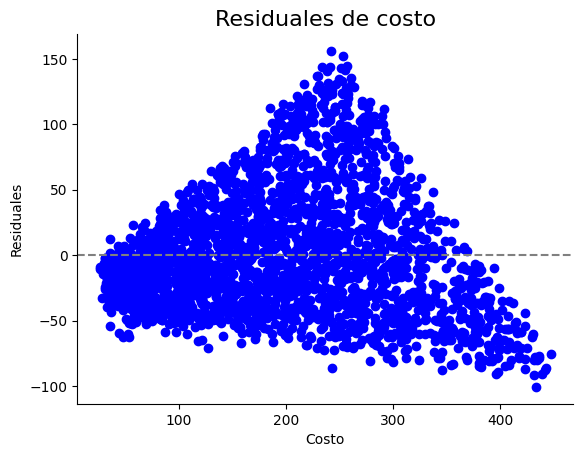

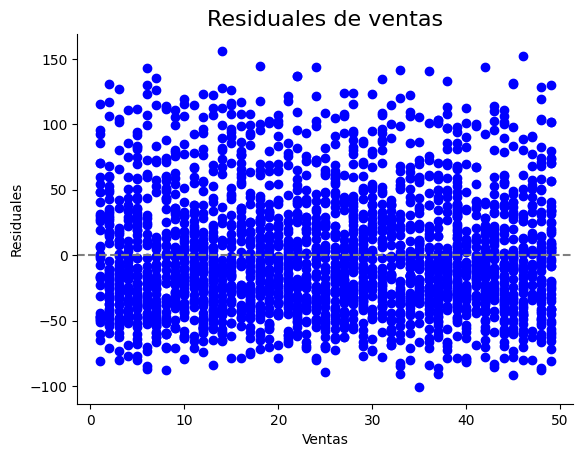

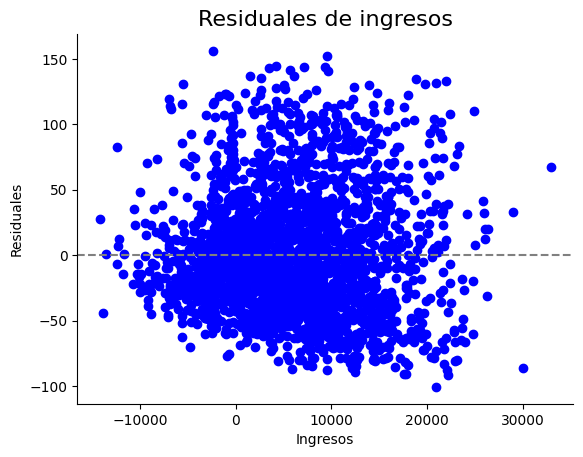

In [ ]:
x = df[["costo", "ventas",	"categoria",	"material",	"color",	"locacion",	"temporada","marca", "ingresos"]]
y = df["precio"]
#Ho=Ninguna variable independiente tiene efecto significativo sobre el consumo de energía.
#H1=Al menos una de las variables independientes tiene un efecto significativo.
# 6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de
# dispersión.
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()

yc = modelo.predict(x_constante)



# 5. Calcule el coeficiente de determinación e interprete el resultado.
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, yc)
print(f'Coeficiente de determinación: {r2: 0.4f}\n')


#Expresión matemática
print(modelo.params,"\n")


# 8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente,
# ¿Parece que se verifican los supuestos?
residuales = modelo.resid
plt.scatter(x["costo"], residuales, color = 'blue')
plt.xlabel('Costo')
plt.ylabel('Residuales')
plt.axhline(y = 0, color = 'gray', linestyle = '--')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title("Residuales de costo", fontsize=16)

plt.figure()
plt.scatter(x["ventas"], residuales, color = 'blue')
plt.xlabel('Ventas')
plt.ylabel('Residuales')
plt.axhline(y = 0, color = 'gray', linestyle = '--')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title("Residuales de ventas", fontsize=16)


plt.figure()
plt.scatter(x["ingresos"], residuales, color = 'blue')
plt.xlabel('Ingresos')
plt.ylabel('Residuales')
plt.axhline(y = 0, color = 'gray', linestyle = '--')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title("Residuales de ingresos", fontsize=16)


# 9. Realice la prueba de Shapiro para los residuales y comente el resultado.
from scipy.stats import shapiro
_, valor_p_sh = shapiro(residuales)
print(f'valor-p de Shapiro: {valor_p_sh: 0.4f}\n')


# 10. Realice la prueba de Breusch-Pagan para los residuales y comente el
# resultado.
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')



#12
from statsmodels.formula.api import ols
modelo_lineal = ols('precio ~ costo + ventas + C(categoria) + C(material) + C(color) + C(locacion) + C(temporada) + C(marca) + ingresos', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

In [ ]:
#f)Modelo matemático de precio de venta.

#ECUACIÓN:
#Precio venta estimado=43.061612+1.199255(costo)-0.443536(ventas)+0.388684(categoría)-0.019127(material)+0.483738(color)+1.009411(locacion)+0.067359(temporada)+0.089745(marca)+0.001530(ingresos)

#EXPLICACIÓN BREVE DE CADA TÉRMINO:
#La ecuación parte de una constante o intercepto de 43.061612, que representa el precio base. Cada variable ajusta este valor:
#Costo (+1.199255): A mayor costo, mayor precio.
#Ventas (−0.443536): Más ventas tienden a reducir ligeramente el precio.
#Categoría (+0.388684): Categorías superiores aumentan el precio.
#Material (−0.019127): Algunos materiales reducen el precio.
#Color (+0.483738): Ciertos colores elevan el precio.
#Locación (+1.009411): La ubicación incrementa el precio.
#Temporada (+0.067359): En ciertas temporadas el precio sube levemente.
#Marca (+0.089745): Marcas mejor valoradas aumentan el precio.
#Ingresos (+0.001530): Clientes con mayores ingresos pagan precios ligeramente más altos.

In [ ]:
#g)Evaluación del modelo
#ANÁLISIS DE LOS RESIDUALES DEL MODELO Y LOS ESTADSTÍCOS PRINCIPALES
#El modelo presenta un coeficiente de determinación de 0.8744 lo que indica que explica el 87.44% de la variabilidad del precio, mostrando un buen nivel de predicción. Sin embargo, al realizar el análisis de los residuales este nos revela que no se cumplen los supuestos básicos de la regresión lineal:
#En la variable costo, hay un patrón y las varianzas no son constantes por lo que no hay homoscedasticidad ni linealidad incluyendo asi mismo que no hay normalidad.
#En ventas, los residuales parecen aleatorios y van comi en linea imaginaria y cumple con linealidad, pero también presenta que no hay homoscedasticidad y ni normalidad respecto a los test con valor cero.
#En ingresos, los residuales son centrados y nos indica que hay linealidad, pero igualmente falta homoscedasticidad y normalidad respecto a los test.
#Por lo que, aunque el modelo tiene un buen ajuste general, no cumple con los supuestos de linealidad, homoscedasticidad y normalidad respecto a los test, lo que limita su validez.

#MODELO DEL CLIENTE

Coeficiente de determinación:  0.8703

const        33.207913
costo         1.237777
categoria     0.333828
material     -0.264587
color         0.585274
locacion      1.424888
temporada     0.317783
marca         0.099022
dtype: float64 

valor-p de Shapiro:  0.0000

valor_p de Breusch-Pagan:  0.0000



,df,sum_sq,mean_sq,F,PR(>F)
C(categoria),4.0,9.657745e+04,2.414436e+04,10.808994,1.095717e-08
C(material),4.0,8.895205e+04,2.223801e+04,9.955555,5.435926e-08
C(color),5.0,3.360018e+04,6.720036e+03,3.008438,1.033769e-02
C(locacion),2.0,6.284114e+04,3.142057e+04,14.066420,8.422919e-07
C(temporada),3.0,3.940800e+04,1.313600e+04,5.880750,5.360486e-04
C(marca),3.0,3.188341e+04,1.062780e+04,4.757875,2.601473e-03
costo,1.0,3.693267e+07,3.693267e+07,16534.086298,0.000000e+00
Residual,2477.0,5.532947e+06,2.233729e+03,NaN,NaN


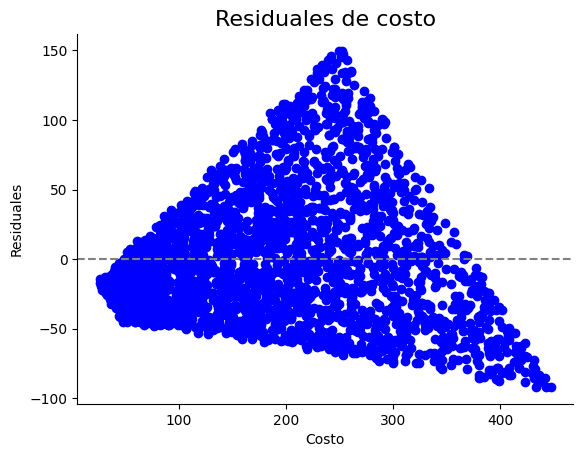

In [ ]:
x = df[["costo", "categoria",	"material",	"color",	"locacion",	"temporada","marca"]]
y = df["precio"]
#Ho=Ninguna variable independiente tiene efecto significativo sobre el consumo de energía.
#H1=Al menos una de las variables independientes tiene un efecto significativo.
# 6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de
# dispersión.
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()

yc = modelo.predict(x_constante)



# 5. Calcule el coeficiente de determinación e interprete el resultado.
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, yc)
print(f'Coeficiente de determinación: {r2: 0.4f}\n')


#Expresión matemática
print(modelo.params,"\n")


# 8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente,
# ¿Parece que se verifican los supuestos?
residuales = modelo.resid
plt.scatter(x["costo"], residuales, color = 'blue')
plt.xlabel('Costo')
plt.ylabel('Residuales')
plt.axhline(y = 0, color = 'gray', linestyle = '--')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title("Residuales de costo", fontsize=16)



# 9. Realice la prueba de Shapiro para los residuales y comente el resultado.
from scipy.stats import shapiro
_, valor_p_sh = shapiro(residuales)
print(f'valor-p de Shapiro: {valor_p_sh: 0.4f}\n')


# 10. Realice la prueba de Breusch-Pagan para los residuales y comente el
# resultado.
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')



#12
from statsmodels.formula.api import ols
modelo_lineal = ols('precio ~ costo + C(categoria) + C(material) + C(color) + C(locacion) + C(temporada) + C(marca)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

In [ ]:
#f)Modelo matemático de precio de venta cliente.

#ECUACIÓN:
#Precio venta estimado=33.207913+1.237777(costo)+0.333828(categoría)-0.264587(material)+0.585274(color)+1.424888(locacion)+0.317783(temporada)+0.099022(marca)

#EXPLICACIÓN BREVE DE CADA TÉRMINO:
#La ecuación parte de una constante o intercepto de 43.061612, que representa el precio base. Cada variable ajusta este valor:
#Costo (+0.333828): A mayor costo, mayor precio.
#Categoría (+0.388684): Categorías superiores aumentan el precio.
#Material (-0.264587): Algunos materiales reducen el precio.
#Color (+0.585274): Ciertos colores elevan el precio.
#Locación (+1.424888): La ubicación incrementa el precio.
#Temporada (+0.317783): En ciertas temporadas el precio sube levemente.
#Marca (+0.099022): Marcas mejor valoradas aumentan el precio.

In [ ]:
#g)Evaluación del modelo
#El modelo del cliente explica el 87.03% de la variabilidad del precio, lo que indica un buen nivel de ajuste. Sin embargo, al realizar el análisis de los residuales nos muestra
#que hay una forma triangular con mayor dispersión al centro y al exterior no, lo que evidencia que no se cumplen los supuestos de linealidad, homoscedasticidad ni
#normalidad en donde los tests de Shapiro y Breusch-Pagan con valor cero confirman la falta de los dos últimos supuestos. Por lo que, aunque el modelo predice ,
#no es completamente confiable para obtener conclusiones estadísticas.